## Importing File

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("STD Cases.csv")
# print(df.head)

## Disease That Has the Highest Total Recorded Cases in America

Disease
Chlamydia                         18991264.0
Gonorrhea                          6454097.0
Primary and Secondary Syphilis      205913.0
Name: STD Cases, dtype: float64


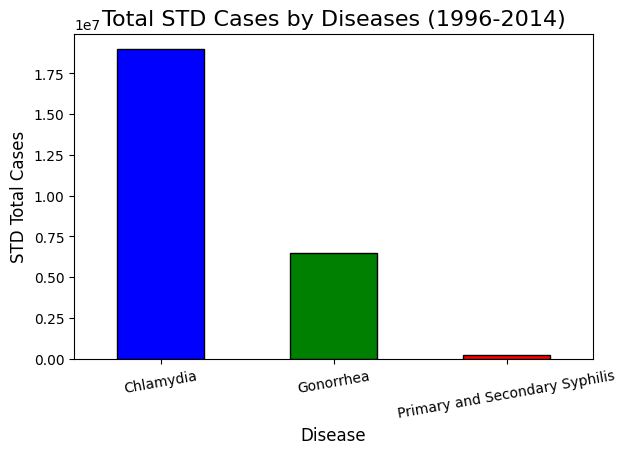

In [2]:
# Total Cases for each Disease

cases_diseases = df.groupby("Disease")["STD Cases"].sum()
print(f"{cases_diseases}")

cases_diseases.plot(
    kind = "bar",
    color = ["blue", "green", "red"],
    edgecolor = "black"
)
plt.title("Total STD Cases by Diseases (1996-2014)", fontsize = 16)
plt.xlabel("Disease", fontsize = 12)
plt.ylabel("STD Total Cases", fontsize = 12)
plt.xticks(rotation = 10)
plt.tight_layout()
plt.savefig("Total_STD_Cases_by_Diseases_(1996-2014)")
plt.show()

In [3]:
# Disease with the highest and lowest numbers of cases

high_disease = cases_diseases.idxmax()
high_cases = cases_diseases.max()
low_disease = cases_diseases.idxmin()
low_cases = cases_diseases.min()
print(f"Disease with the highest case is {high_disease}")
print(f"Total case = {high_cases}")
print(f"Disease with the lowest case is {low_disease}")
print(f"Total case = {low_cases}")

Disease with the highest case is Chlamydia
Total case = 18991264.0
Disease with the lowest case is Primary and Secondary Syphilis
Total case = 205913.0


In [4]:
# How much the highest case outnumbered the lowest case

case_difference = high_cases - low_cases
print(f"Highest case exceeded the lowest case with a number of {case_difference}")

Highest case exceeded the lowest case with a number of 18785351.0


## Average Rate per 100k people for each of the three diseases across all states, years, and age groups

In [5]:
avg_rate = df.groupby("Disease")["Rate per 100K"].mean().round(2)
print(f"The average rate per 100,000 people for each of the three diseases: {avg_rate}")

The average rate per 100,000 people for each of the three diseases: Disease
Chlamydia                         652.43
Gonorrhea                         202.36
Primary and Secondary Syphilis      7.09
Name: Rate per 100K, dtype: float64


In [6]:
# finding the diseases with the highest average rate
high_disease_name = avg_rate.idxmax()
high_rate = avg_rate.max()
print(f"Disease with the highest average rate is {high_disease_name}")
print (f"Average rate: {high_rate}")

Disease with the highest average rate is Chlamydia
Average rate: 652.43


## Median rate per 100,000 people for males versus females across this entire dataset

In [7]:
med_rate = df.groupby("Gender")["Rate per 100K"].median()
print(med_rate)

Gender
Female     59.27
Male       45.55
Unknown      NaN
Name: Rate per 100K, dtype: float64


In [8]:
# Gender with the highest median rate
high_med_gender = med_rate.idxmax()
high_rate = med_rate.max()
print(f"Gender with the highest median rate is {high_med_gender}")
print (f"Median rate: {high_rate}")

Gender with the highest median rate is Female
Median rate: 59.27


## STD awareness campaigns at the age groups most affected

In [16]:
# counting each age group in the dataset
count_age = df["Age"].value_counts()
print(f"Range count for {count_age}")

Range count for Age
20-24 years    6082
25-29 years    5940
15-19 years    5871
40+ years      5836
30-34 years    5786
35-39 years    5674
0-14 years     4203
Unknown        3138
Name: count, dtype: int64


In [10]:
# frequent age group
common_age = count_age.idxmax()
frequency = count_age.max()
print(f"Most frequent age group is {common_age}")
print (f"Frequency: {frequency}")

Most frequent age group is 20-24 years
Frequency: 6082


## Top 5 states with the highest total STD cases across all years, all diseases and how they compare

Top 5 state with the highest STD cases were: State
Alabama        569174.0
Alaska          89281.0
Arizona        477074.0
Arkansas       270043.0
California    2922206.0
Name: STD Cases, dtype: float64


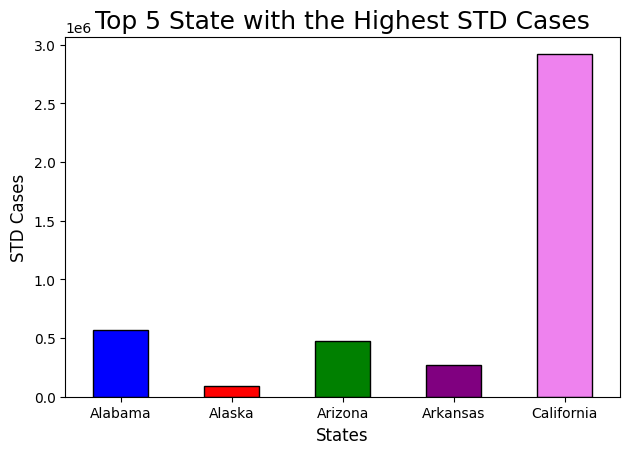

In [11]:
# Total STD cases for each state
all_stateSTD = df.groupby("State")["STD Cases"].sum()
# print(f"Total STD cases for each state: {all_stateSTD}")

top5_state = all_stateSTD.head(5)
print(f"Top 5 state with the highest STD cases were: {top5_state}")

top5_state.plot(
    kind = "bar",
    color = ["blue", "red", "green", "purple", "violet"],
    edgecolor = "black" 
)
plt.title("Top 5 State with the Highest STD Cases", fontsize = 18)
plt.xlabel("States", fontsize = 12)
plt.ylabel("STD Cases", fontsize = 12)
plt.xticks(rotation = 0)
plt.tight_layout()
plt.savefig("Top5_State_with_STD_Cases.png")
plt.show()

## Was the average rate per 100,000 people going up, going down, or staying the same over those 19 years?

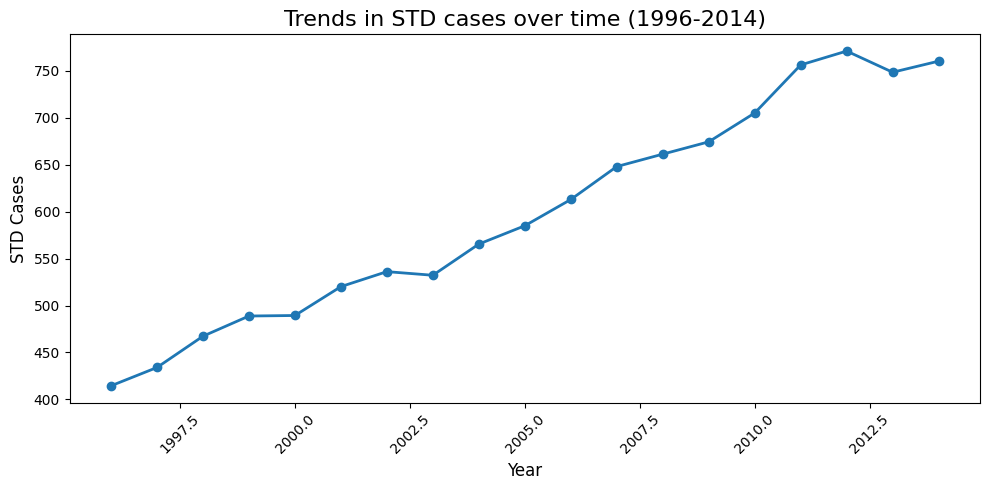

In [12]:
avg_rate_year = df.groupby("Year")["STD Cases"].mean().round(2)
# print(f"Average rate of STD cases over those 19 {avg_rate_year}")

# Line chart
plt.figure(figsize = (10,5))
plt.plot(
    avg_rate_year.index,
    avg_rate_year.values,
    marker = "o",
    linewidth = 2
)
plt.title("Trends in STD cases over time (1996-2014)", fontsize = 16)
plt.xlabel("Year", fontsize = 12)
plt.ylabel("STD Cases", fontsize = 12)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.savefig("Trends_STD_cases_over_those_19years.png")
plt.show()

## Proportion of the total belongs to Chlamydia, what proportion to Gonorrhea, and what proportion to Syphilis

Disease
Chlamydia                         18991264.0
Gonorrhea                          6454097.0
Primary and Secondary Syphilis      205913.0
Name: STD Cases, dtype: float64


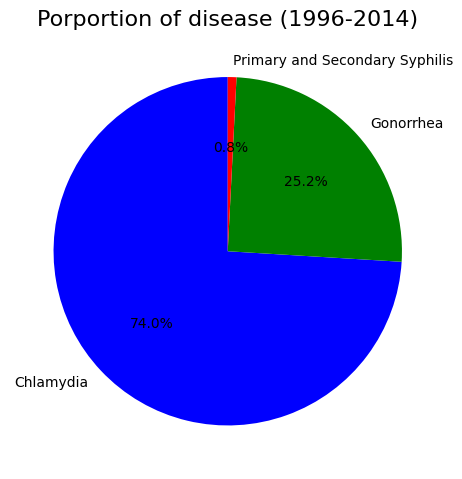

In [13]:
disease_cases = df.groupby("Disease")["STD Cases"].sum()
print(disease_cases)

# pie chart
plt.figure(figsize = (5,5))
disease_cases.plot(
    kind = "pie",
    colors = ["blue", "green", "red"],
    autopct = "%1.1f%%",
    startangle = 90
)
plt.title("Porportion of disease (1996-2014)", fontsize = 16)
plt.tight_layout()
plt.savefig("Percentage_per_disease.png")
plt.show()

## Relationship between Population and STD Cases

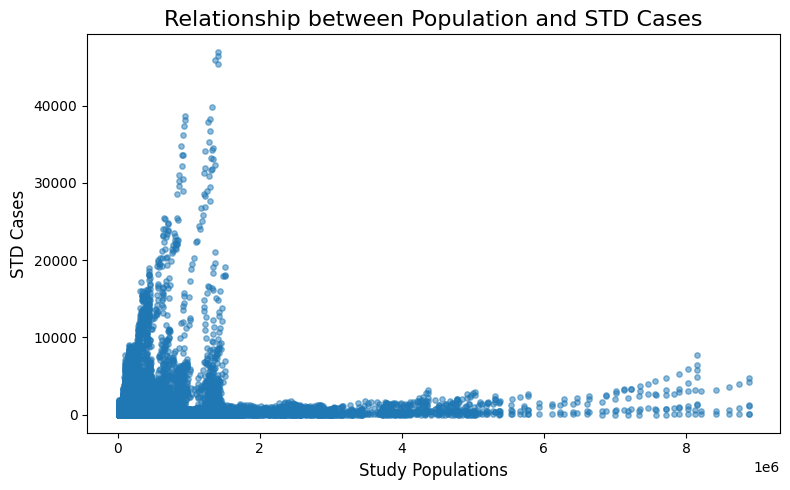

In [14]:
plt.figure(figsize = (8,5))
plt.scatter(
    df["Population"],
    df["STD Cases"],
    s = 15,
    alpha = 0.5
)
plt.title("Relationship between Population and STD Cases", fontsize = 16)
plt.xlabel("Study Populations", fontsize = 12)
plt.ylabel("STD Cases", fontsize = 12)
plt.tight_layout()
plt.savefig("Relationship_btw_STD_&_Population.png")
plt.show()
